### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [ ]:
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
# move unnamed and train columns
df = df.drop(columns=[df.columns[0],df.columns[-1]])

**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

The pairplot function generates a matrix of plots to visualize relationships between all variables in the dataset.

- n_vars = df.shape[1]: Determines the number of variables (columns).
- plt.subplots(...): Creates the figure and a grid of subplots. ax is a 2D array of axes objects.
- plt.subplots_adjust(...): Fine-tunes the spacing between plots so they don't overlap.
- axij.set_xticks([]) / set_yticks([]): Removes axis labels from individual plots.
- if i != j: axij.scatter(...): Plots a scatter plot when comparing two different variables. This visualizes the correlation.
- else: axij.text(...): On the diagonal, it displays the variable name instead of a plot.
- transform = axij.transAxes: Ensures the text is centered relative to the subplot boundaries rather than data coordinates.

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

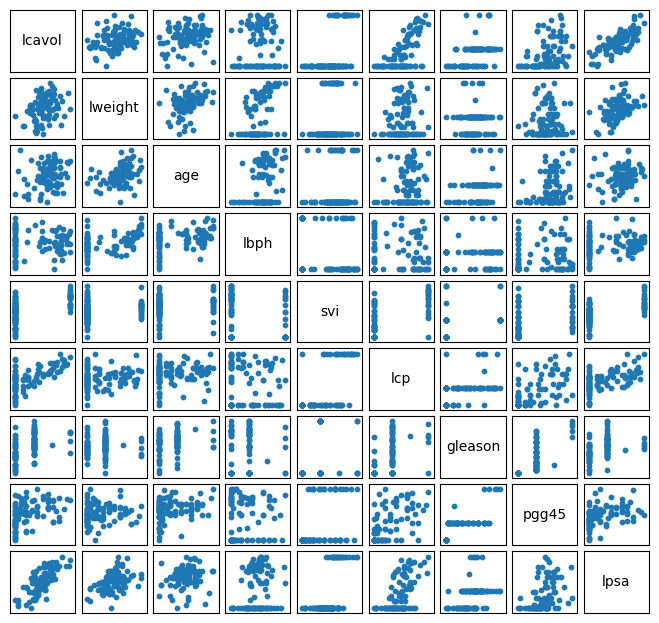

In [ ]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95)
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

c) The variables that appear most correlated with lcavol are:
- lpsa
- lcp

#### Quantitative : 
lcavol, lweight, age, lbph, lcp, lpsa, and pgg45.

#### Categorical : 
svi (seminal vesicle invasion) is binary. gleason is categorical, as it only takes a few discrete integer values (4 values).

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

For two vectors $X = (x_1, \dots, x_n)$ and $Y = (y_1, \dots, y_n)$,  
the Pearson correlation coefficient is defined as:

$$
\mathrm{corr}(X,Y) =
\frac{
\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
}{
\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2}
\sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}
}
$$

where $\bar{x}$ and $\bar{y}$ denote the means of $X$ and $Y$.

In [ ]:
import numpy as np


def correlation(x, y):
    x = np.array(x)
    y = np.array(y)
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean)**2)) * np.sqrt(np.sum((y - y_mean)**2))
    
    return numerator / denominator

print(correlation(df["lcavol"], df["lpsa"]))

print(df.corr().loc["lcavol", "lpsa"])


0.734460326213673
0.734460326213673


/home/ensimag/Bureau/Stats/Stats-S8-TPs/venv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


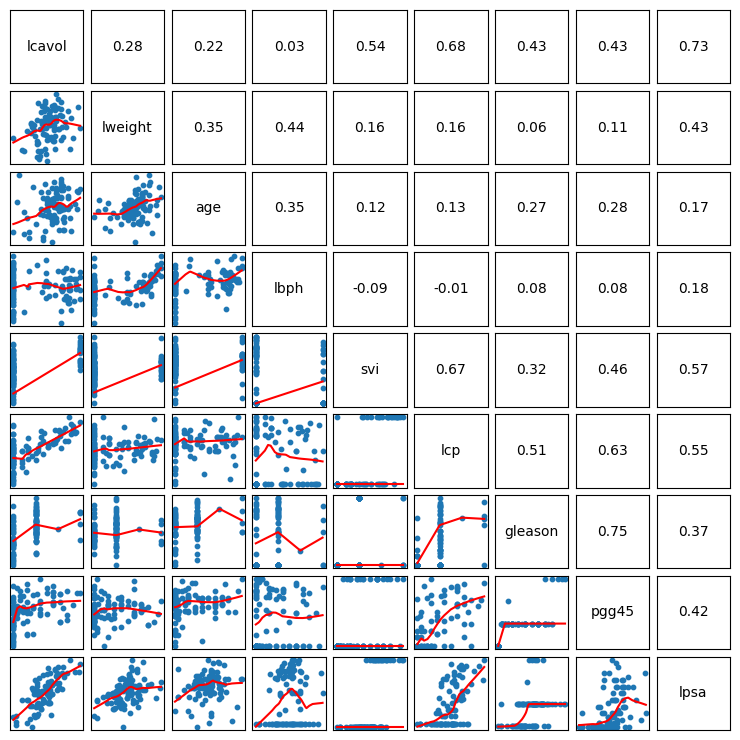

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def pairplot_corr(df, figsize=None):
    if figsize is None:
        figsize = (8, 8)
        
    n_vars = df.shape[1]
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    
    plt.subplots_adjust(
        wspace=0.1, hspace=0.1,
        left=0.05, right=0.95,
        bottom=0.05, top=0.95
    )
    
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            
            axij.set_xticks([])
            axij.set_yticks([])
            
            if i > j :
                axij.scatter(df[i_name], df[j_name], s=10)
                z = lowess(df[j_name], df[i_name], frac=0.5)
                axij.plot(z[:, 0], z[:, 1], color='red', lw=1.5)
                
            elif i < j :
                corr = correlation(df[i_name], df[j_name])
                axij.text(0.5, 0.5, f"{corr:.2f}",
                          horizontalalignment='center',
                          verticalalignment='center',
                          transform=axij.transAxes,
                          fontsize = 10)
                
            else :
                axij.text(0.5, 0.5, i_name,
                          horizontalalignment='center',
                          verticalalignment='center',
                          transform=axij.transAxes,
                          fontsize = 10)
                
    return fig, ax

fig, ax = pairplot_corr(df)
plt.show()

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

We model the variable $lcavol$ using a multiple linear regression with predictors
$lweight$, $age$, $lbph$, $lcp$, $pgg45$, $lpsa$, and the categorical variables $svi$ and $gleason$.

The regression model can be written as:

$$
lcavol_i =
\beta_0
+ \beta_1 lweight_i
+ \beta_2 age_i
+ \beta_3 lbph_i
+ \beta_4 lcp_i
+ \beta_5 pgg45_i
+ \beta_6 lpsa_i
+ \beta_7 svi_{i,1}
+ \beta_8 gleason_{i,7}
+ \beta_9 gleason_{i,8}
+ \beta_{10} gleason_{i,9}
+ \varepsilon_i
$$

where:

- $i$ is the observation index
- $\beta_0$ is the intercept
- $\beta_1, \dots, \beta_{10}$ are the regression coefficients
- $\varepsilon_i$ is the error term

Categorical variables are represented using dummy variables:

- $svi_{i,1} = 1$ if svi = 1, otherwise 0
- $gleason_{i,k} = 1$ if gleason = k, otherwise 0


**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

In [ ]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']

- Why did we fix a `dtype` in `pd.get_dummies`?

We fixed the `dtype` to ensure that the generated dummy variables are numerical (typically floats), rather than boolean values (true or false).
Linear regression models require numerical inputs to perform matrix operations. By explicitly setting the dtype (e.g., `dtype=float`), we ensure compatibility with libraries such as NumPy and statsmodels, and avoid potential type-related issues during model fitting.

- Why did we drop two columns after the encoding?

We dropped one dummy variable per categorical variable to avoid multicollinearity.Dummy variables created from a categorical variable are linearly dependent because their sum equals 1. This creates perfect multicollinearity, which makes the regression coefficients impossible to estimate uniquely.

- Why did we add a column of ones to the dataframe?

We added a column of ones to include the intercept term in the regression model. The intercept represents the baseline value of the response variable when all predictors are equal to zero.


**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [ ]:
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        19:26:18   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.958      -0.432       0.409
age            0.0248      0.011      2.205      0.030       0.002       0.047
lbph          -0.1042      0.058     -1.790      0.077      -0.220       0.012
lcp            0.4028      0.085      4.734      0.000       0.234       0.572
pgg45         -0.0094      0.005     -2.080      0.040      -0.018      -0.000
lpsa           0.5496      0.090      6.100      0.000       0.370       0.729
svi_1         -0.2204      0.256     -0.860      0.392      -0.730       0.289
gleason_7      0.3117      0.215      1.448      0.151      -0.116       0.740
gleason_8     -0.7106      0.759     -0.936      0.352      -2.219       0.798
gleason_9      0.7901      0.488      1.621      0.109      -0.179       1.759
intercept     -1.4067      0.874     -1.609      0.111      -3.145       0.332
==============================================================================
Omnibus:                        0.107   Durbin-Watson:                   2.306
Prob(Omnibus):                  0.948   Jarque-Bera (JB):                0.127
Skew:                          -0.073   Prob(JB):                        0.939
Kurtosis:                       2.900   Cond. No.                         884.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`.

    The variables `svi` and `gleason` were encoded using dummy variables. Their coefficients represent the difference in the expected value of `lcavol` compared to their reference categories, while holding all other variables constant.

    For `svi`:

    - The reference category is `svi = 0`.
    - The coefficient for `svi_1` is −0.2204.

    This means that, on average, patients with `svi = 1` have a predicted `lcavol` that is 0.2204 units lower than patients with `svi = 0`, all else being equal.

    However, the p-value is 0.392, which is greater than 0.05. This indicates that this effect is not statistically significant.

    For `gleason`:

    - The reference category is `gleason = 6`.
    - Each coefficient represents the difference compared to this reference.

    Specifically:

    - `gleason_7`: coefficient = 0.3117  
    Patients with gleason score 7 have a predicted lcavol higher by 0.3117 compared to gleason 6.

    - `gleason_8`: coefficient = −0.7106  
    Patients with gleason score 8 have a predicted lcavol lower by 0.7106 compared to gleason 6.

    - `gleason_9`: coefficient = 0.7901  
    Patients with gleason score 9 have a predicted lcavol higher by 0.7901 compared to gleason 6.

    However, all p-values for gleason variables are greater than 0.05, which means that these effects are not statistically significant.

- What would have happened in the regression if we did not do the one-hot encoding from above?

If we had not performed one-hot encoding, the regression model would treat the categorical variables as continuous numerical variables. This would incorrectly assume an ordinal and linear relationship between categories. For example, the model would assume that the difference between gleason 6 and 7 is the same as between 8 and 9, which may not be true. This would lead to incorrect coefficient estimation and poor interpretation of the categorical effects. Additionally, the model would not be able to properly distinguish between categories.

- Comment the overall results of the regression as well.

    - The model has an R-squared value of 0.686 and an adjusted R-squared of 0.650. This means that approximately 68.6% of the variability in lcavol is explained by the predictors, which indicates a reasonably good fit.

    - The F-statistic p-value is extremely small (9.05e-18), which means that the overall model is statistically significant.

    Among the predictors:

        Statistically significant variables (p-value < 0.05):

        - age (p = 0.030)
        - lcp (p < 0.001)
        - pgg45 (p = 0.040)
        - lpsa (p < 0.001)

    The strongest predictor is lpsa, with a coefficient of 0.5496 and a very small p-value.

    Variables that are not statistically significant include:

    - lweight
    - svi
    - gleason variables

    This suggests that these variables may not have a strong independent effect on lcavol in this model.

    Overall, the model provides a good fit, and lpsa and lcp appear to be the most important predictors of lcavol.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [ ]:
results.conf_int(alpha=0.05)

,0,1
lweight,-0.431600,0.409107
age,0.002436,0.047129
lbph,-0.219914,0.011515
lcp,0.233639,0.571880
pgg45,-0.018469,-0.000419
lpsa,0.370474,0.728673
svi_1,-0.730029,0.289190
gleason_7,-0.116263,0.739616
gleason_8,-2.219087,0.797911
gleason_9,-0.179004,1.759273


### Interpretation of the Results

#### Significant predictors (interval does not contain 0):

- **age**: [0.0024 , 0.0471]  
  The interval is entirely positive, which indicates a statistically significant positive effect on `lcavol`.

- **lcp**: [0.2336 , 0.5719]  
  Strong positive and significant effect.

- **pgg45**: [-0.0185 , -0.0004]  
  Entirely negative interval → statistically significant negative effect.

- **lpsa**: [0.3705 , 0.7287]  
  Strong positive and highly significant effect. This appears to be the most influential predictor.


#### Non-significant predictors (interval contains 0):

- **lweight**: [-0.4316 , 0.4091]
- **lbph**: [-0.2199 , 0.0115]
- **svi_1**: [-0.7300 , 0.2892]
- **gleason_7**: [-0.1163 , 0.7396]
- **gleason_8**: [-2.2191 , 0.7979]
- **gleason_9**: [-0.1790 , 1.7593]
- **intercept**: [-3.1450 , 0.3317]

Since these intervals include 0, we cannot conclude that their effects are statistically different from zero at the 5% level.


The confidence intervals confirm the conclusions drawn from the p-values:

- `lpsa` and `lcp` are strong positive predictors.
- `age` has a moderate positive effect.
- `pgg45` has a small but significant negative effect.
- The categorical variables (`svi` and `gleason`) do not appear to have statistically significant effects in this model.

Overall, the model suggests that `lpsa` is the most important predictor of `lcavol`, while the Gleason score and `svi` do not provide significant additional explanatory power in this regression.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [ ]:
results.pvalues

lweight      9.577075e-01
age          3.014993e-02
lbph         7.695609e-02
lcp          8.577858e-06
pgg45        4.047741e-02
lpsa         2.939241e-08
svi_1        3.922717e-01
gleason_7    1.512950e-01
gleason_8    3.516744e-01
gleason_9    1.087313e-01
intercept    1.113676e-01
dtype: float64

The variable `lpsa` has a strong and statistically significant positive effect on the response variable `lcavol`.

From the regression results, the estimated coefficient for `lpsa` is positive (0.5496), which means that an increase of one unit in `lpsa` is associated with an average increase of approximately 0.55 units in `lcavol`, holding all other variables constant.

The p-value for `lpsa` is extremely small:

$$
p = 2.94 \times 10^{-8}
$$

This p-value is much smaller than the standard significance level of 0.05.

In hypothesis testing, we test:
    - Null hypothesis ($H_0$): the coefficient of `lpsa` is equal to 0 (no effect)
    - Alternative hypothesis ($H_1$): the coefficient of `lpsa` is different from 0

Since the p-value is much smaller than 0.05, we reject the null hypothesis. This provides very strong evidence that `lpsa` has a significant effect on `lcavol`.

The 95% confidence interval for `lpsa` is:

$$
[0.3705,\ 0.7287]
$$

This interval does not include 0, which confirms that the effect of `lpsa` is statistically significant.

Additionally, since the entire interval is positive, it indicates that the effect of `lpsa` on `lcavol` is positive.

Both the hypothesis test (p-value) and the confidence interval confirm that `lpsa` is a highly significant predictor of `lcavol`.
It is one of the most important variables in the model and has a strong positive influence on the response variable.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [ ]:


def resolution(X,y):
    X = np.asarray(X)
    y = np.asarray(y).reshape(-1, 1)
    
    n,p =  X.shape
    
    inv = np.linalg.inv(X.T @ X)
    beta_hat = inv @ X.T @ y
    
    y_hat = X @ beta_hat
    
    error = y - y_hat
    
    #pvalues
    




**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

In [ ]:
results.get_prediction().predicted_mean

array([-0.84931804, -0.50981534,  0.0165697 , -0.50940106, -0.11843628,
       -0.19705697, -0.06140832, -0.2580006 , -0.12000038,  0.27983549,
        0.44605822,  0.12008817,  0.74895047,  0.81147863,  0.97133742,
        0.57585573,  0.75447846,  1.30250587,  0.01509834,  0.43294446,
        0.50390991,  1.46431424,  0.47426807,  1.23177297,  0.48876069,
        0.62458536,  0.62508691,  0.583746  ,  0.7870086 ,  2.00414299,
        0.68957863,  0.52910047,  0.73204035,  0.59194356,  1.06666193,
        0.75917844,  1.42310833,  1.11331215,  1.80489935,  1.30026076,
        0.92837504,  1.3086603 ,  1.01330839,  2.09250653,  1.34354295,
        1.0177391 ,  2.41748666,  1.22675103,  0.62998589,  1.24746766,
        1.11931171,  0.82895977,  1.12855065,  2.04385496,  1.35296807,
        1.06512666,  1.87820348,  0.59434778,  1.34223026,  0.84805618,
        1.11272158,  1.99491433,  2.57127508,  1.93408583,  1.30865488,
        1.46044335,  1.83707285,  1.76362631,  1.46807706,  1.65

The fitted regression model is:

$$
lcavol =
\beta_0
+ \beta_1 lweight
+ \beta_2 age
+ \beta_3 lbph
+ \beta_4 lcp
+ \beta_5 pgg45
+ \beta_6 lpsa
+ \beta_7 svi_1
+ \beta_8 gleason_7
+ \beta_9 gleason_8
+ \beta_{10} gleason_9
$$


**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [ ]:
X_without_l = df_enc.drop(columns=['lcavol','lpsa', 'lcp'])

model_without_l = sm.OLS(y, X_without_l)
results_without_l = model_without_l.fit()

results_without_l.summary()
#results_without_l.conf_int(alpha=0.05)
#results_without_l.pvalues
#sm.qqplot(y-results_without_l.get_prediction().predicted_mean)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lcavol   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     8.390
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           2.11e-08
Time:                        21:05:09   Log-Likelihood:                -125.58
No. Observations:                  97   AIC:                             269.2
Df Residuals:                      88   BIC:                             292.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight        0.5850      0.259      2.257      0.026       0.070       1.100
age            0.0073      0.015      0.497      0.621      -0.022       0.036
lbph          -0.0746      0.077     -0.967      0.336      -0.228       0.079
pgg45         -0.0004      0.006     -0.076      0.939      -0.012       0.011
svi_1          1.0246      0.271      3.774      0.000       0.485       1.564
gleason_7      0.8007      0.274      2.918      0.004       0.255       1.346
gleason_8      0.6869      0.960      0.715      0.476      -1.221       2.595
gleason_9      1.1726      0.644      1.820      0.072      -0.108       2.453
intercept     -1.9717      1.159     -1.701      0.092      -4.275       0.332
==============================================================================
Omnibus:                        0.297   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.862   Jarque-Bera (JB):                0.473
Skew:                          -0.013   Prob(JB):                        0.789
Kurtosis:                       2.659   Cond. No.                         882.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

When the predictors `lpsa` and `lcp` are removed from the multiple linear regression model, the performance and explanatory power of the model decrease significantly.

First, the coefficient of determination is relatively low, with an $R^2 = 0.433$ and an adjusted $R^2 = 0.381$. This means that the model now explains only about 43.3% of the variability in the response variable `lcavol`. In comparison to the full model (which included `lpsa` and `lcp`), this represents a substantial loss of explanatory power.

This result is expected because, in the full model, `lpsa` and `lcp` had very small p-values (especially `lpsa`, which had an extremely significant p-value). This indicates that they were very important predictors of the response variable. Removing important predictors leads to a weaker model with lower predictive accuracy.

Additionally, after removing these variables, some other predictors become more statistically significant. For example, `lweight` (p-value = 0.026), `svi_1` (p-value < 0.001), and `gleason_7` (p-value = 0.004) are now significant predictors. This happens because removing correlated predictors can redistribute the explained variance among the remaining variables.

However, several predictors remain non-significant, such as `age`, `lbph`, `pgg45`, `gleason_8`, and the intercept, since their p-values are greater than 0.05. This suggests that they do not have strong evidence of an effect on the response variable in this reduced model.

In conclusion, removing `lpsa` and `lcp` substantially weakens the model.


## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

In [ ]:
#(a) Finding the best model with two parameters k=2 using itertools.combinations
import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm

df = pd.read_csv("prostate.data", sep="\t")
df = df.drop(columns=[df.columns[0], df.columns[-1]])

y = df["lcavol"]

predictors = df.columns.drop("lcavol")

results = []

for combo in itertools.combinations(predictors, 2):
    
    X = df[list(combo)]
    X = sm.add_constant(X) 
    
    model = sm.OLS(y, X).fit()
    
    rss = np.sum(model.resid ** 2)
    
    results.append((combo, rss))

results_df = pd.DataFrame(results, columns=["Predictors", "RSS"])
results_df = results_df.sort_values(by="RSS")


# Display best model
print(results_df)

AttributeError: module 'itertools' has no attribute 'combination'

In [ ]:
#(b) Plotting best models of k parameters against k
best_models = []

for k in range(0, len(predictors)+1):
    
    best_rss_k = np.inf
    best_combo_k = None
    
    # case: k = 0 
    if k == 0:
        X = sm.add_constant(pd.DataFrame(index=df.index))
        model = sm.OLS(y, X).fit()
        best_rss_k = np.sum(model.resid ** 2)
        best_combo_k = ()
    
    else:
        for combo in itertools.combinations(predictors, k):
            
            X = sm.add_constant(df[list(combo)])
            model = sm.OLS(y, X).fit()
            rss = np.sum(model.resid ** 2)
            
            if rss < best_rss_k:
                best_rss_k = rss
                best_combo_k = combo
    
    best_models.append((k, best_combo_k, best_rss_k))

best_models_df = pd.DataFrame(best_models, columns=["k", "Predictors", "RSS"])

print(best_models_df)

**(c)** Using just the minimization of the RSS error is not suitable for the following reasons:
- We may always turn to use most of the parameters just as in the case above which is not the most optimal solution and as such we will be having very large models
- Also there are great risks of overfitting on the data due to the complexity of the model, without seprating train data from test data it will be more amplified again

In [ ]:
import matplotlib.pyplot as plt

plt.plot(best_models_df["k"], best_models_df["RSS"], marker="o")
plt.xlabel("Model size (k)")
plt.ylabel("RSS")
plt.title("Best RSS as function of model size")
plt.show()

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

**(a)** Split-validation is a model assessment technique in which the available dataset is divided into two subsets: a training set and a validation set. The model is fitted using only the training data, and its results are then evaluated on the validation set. The idea is that the validation data are not used during model training, which allows the evaluation to reflect how well the model generalizes to new observations and avoids overfitting to give best results.

This approach is not subject to the issue discussed in item (c) of the previous Exercise, because the reason why minimizing the residual sum of squares on the training data systematically favors more complex models is because it favors overfitting on the data, which is not the case here. Since the validation error is computed on independent data, overly overfitting models perform worse, while simpler models may generalize better if they are better in general. As a result, split-validation provides a more realistic estimate of the true prediction error and helps balance model fit and complexity.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

training_errors = []
test_errors = []

for k in range(1, 10):
    predictors = best_models[k]
    
    # Add intercept for the non selected predictors
    X_train_k = sm.add_constant(X_train[:, predictors])
    X_test_k = sm.add_constant(X_test[:, predictors])
    
    # Fit the model
    model = sm.OLS(y_train, X_train_k).fit()
    
    # Predictions on the train and the test sets
    y_train_pred = model.predict(X_train_k)
    y_test_pred = model.predict(X_test_k)
    
    # Mean squared errors
    training_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# Plot training and test errors
plt.plot(range(1, 10), training_errors, label="Training error")
plt.plot(range(1, 10), test_errors, label="Test error")
plt.xlabel("Model size k")
plt.ylabel("Mean squared error")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'sklearn'

**(c)** The best model is chosen as the one that minimizes the mean prediction error on the validation set. Unlike training error, the test error here decreases initially as model size increases, then starts to increase once overfitting occurs. The selected model, , therefore represents the best trade-off between bias and variance for this dataset.

**(d)** The main limitations of split-validation are that the results can depend on a particular random choice for the pair of train and validation sets, and that by partitioning the available data into two sets, we drastically reduce the number of samples which can be used for learning the model. 

A solution to this problem is the cross-validation. A test set should still be held out for final evaluation, but the validation set is no longer needed when doing cross-validation. In the basic approach, called k-fold cross-validation, the training set is split into k smaller sets. For each of the k folds, a model is trained using the other folds as training data and the resulting model is validated on the remaining part of the data.

The performance measure reported by k-fold cross-validation is then the average of the values computed in the loop. This approach can be computationally expensive, but does not waste too much data (as is the case when fixing an arbitrary validation set), which is a major advantage in problems such as inverse inference where the number of samples is very small.

Below is an implementation of 10-fold cross-validation applied to the cancer dataset, using the previously selected best models for each model size and fitting them with statsmodels.

In [3]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_errors = []

for k in range(1, 10):
    predictors = best_models[k]
    fold_errors = []
    
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index][:, predictors], X[test_index][:, predictors]
        y_train, y_test = y[train_index], y[test_index]
        
        # Add intercept
        X_train_k = sm.add_constant(X_train)
        X_test_k = sm.add_constant(X_test)
        
        model = sm.OLS(y_train, X_train_k).fit()
        y_pred = model.predict(X_test_k)
        
        fold_errors.append(mean_squared_error(y_test, y_pred))
    
    cv_errors.append(np.mean(fold_errors))

plt.plot(range(1, 10), cv_errors)
plt.xlabel("Model size k")
plt.ylabel("Cross-validated mean squared error")
plt.show()

ModuleNotFoundError: No module named 'sklearn'

The cross-validated error curve is typically smoother than the test error obtained from a single split-validation procedure. On the cancer dataset, cross-validation often selects a simpler model than split-validation, reflecting a better bias–variance trade-off and improved generalization. This illustrates how cross-validation mitigates the instability inherent to a single train–test split and leads to a more robust model selection.

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.